# Forward Propagation and Activation Functions
##### What is forward Propagation ?
  - Process by which input data flows through the layers of neural network to produce an output
  - **Input Layer**
    - Accepts input features and passes them to the next layer
  - **Hidden Layers**
    - Compute weighted sums of inputs, apply biases, and pass the result through activation function
  - **Output Layer**
    - Produces Predictions, typically using an activation function suitable for the task
---
#### Steps in Forward Propagation
  - **Compute Weighted Sum**
    - `z = W * X + b`
    - W: Weights | X: Inputs | b:bias
  - **Apply Activation Function**
    - `a = σ(z)`
      - σ: Activation Function
  - **Repeat for Each Layer**
    - Outputs of one layer bacome inputs to the next
---
### Common Activation Functions
   - **Sigmoid**
     - *Use Case*: Binary Classification in the output layer
     - *Limitation*: Can Suffer from vanishing gradients for large positive/ negative z
   - **Tanh(Hyperbolic Tnagent)**
     - *Use Case:* Hidden layers where zero-centered outputs are prefereed
     - *Limitation:* ALso prone to vainising gradients
   - **ReLU(Rectified Linear Unit)**
     - *Use Cases:* Most commonly used in hidden layers due to simplicity and efficiency
     - *limitation:* Can suffer from the "dying ReLU" problem (neurons stuck at zero)
   - **Softmax**
     - Use Case: Multi-class classification in the output layer
   - 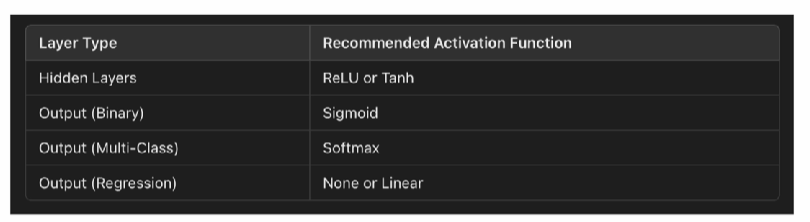

In [20]:
import numpy as np

# Define activation Functions
def sigmoid(z):
    return (1/1+np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0,z)

def softmax(z):
    exp_z = np.exp(z-np.max(z))
    return exp_z/ exp_z.sum(axis=0, keepdims=True)

In [21]:
# Forward pass function
def forward_pass(X, weights, biases, activation_function):
    z = np.dot(weights,X)+biases
    a = activation_function(z)
    return a

In [22]:
# Example inputs
X = np.array([[0.5],[0.8]])
weights = np.array([[0.2,0.4],[0.6,0.1]])
biases = np.array([[0.1],[0.2]])

In [23]:
# Perform forward pass with different activations functions
activations = {
    "Sigmoid": sigmoid,
    "Tanh": tanh,
    "ReLU": relu,
    "Softmax":softmax
}

In [24]:
for name, func in activations.items():
    output = forward_pass(X, weights, biases, func)
    print(f"{name} Activation Outputs: \n{output}\n")

Sigmoid Activation Outputs: 
[[1.59452055]
 [1.55989837]]

Tanh Activation Outputs: 
[[0.47770001]
 [0.52266543]]

ReLU Activation Outputs: 
[[0.52]
 [0.58]]

Softmax Activation Outputs: 
[[0.4850045]
 [0.5149955]]



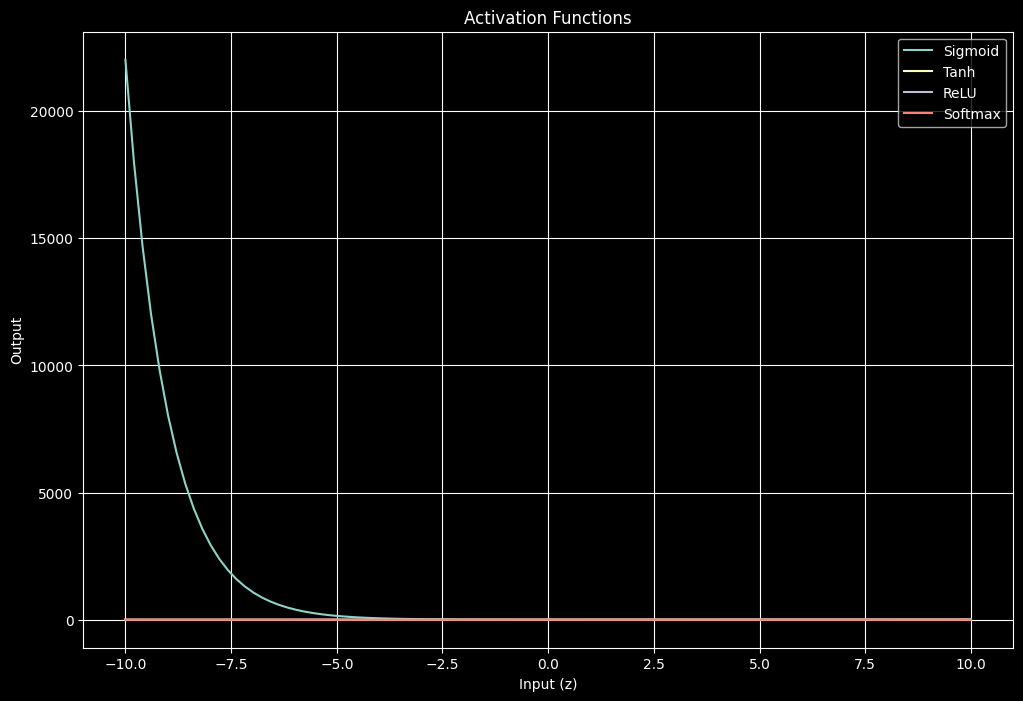

In [25]:
# plotting the them
import matplotlib.pyplot as plt

# Define range of inputs
z = np.linspace(-10,10,100)

# Plot activation function
plt.figure(figsize=(12,8))
plt.plot(z, sigmoid(z), label = "Sigmoid")
plt.plot(z, tanh(z), label = "Tanh")
plt.plot(z, relu(z), label = "ReLU")
plt.plot(z, softmax(z), label="Softmax")
plt.title("Activation Functions")
plt.xlabel('Input (z)')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()